# Notebook 05 — Comparing Training Methods for Unfolded Optimizers

This notebook implements and compares the three training loss formulations discussed
in Lecture 6, applied to the same LISTA architecture:

| Loss | Description |
|------|-------------|
| **L1** | Final-layer loss only (standard end-to-end BPTT) |
| **L2** | Weighted multi-iteration loss (deep supervision at every layer) |
| **L3** | Sequential / greedy — layer *k* trained while 1,…,k−1 are frozen |

We also compare two **parameter-sharing** strategies:

| Architecture | Description |
|---|---|
| **LISTA** | Independent (W_y, W_x, θ) per layer — ~6 M params |
| **LISTA-Tied** | Single (W_y, W_x, θ) shared across all K layers — ~376 K params |

ALISTA (analytic W + learned scalars, 32 params) and HyperLISTA (grid search, 3 params)
are included as structural-prior references.

**Setup:** same synthetic sparse-recovery task as Notebook 02 (m=250, n=500, s=50, K=16).

In [1]:
import sys, os, time, json
sys.path.insert(0, '..')

import torch
import numpy as np
import matplotlib.pyplot as plt

from src.data.sparse_generator import build_sparse_dataloaders
from src.models.lista import LISTA
from src.models.alista import ALISTA
from src.models.hyperlista import HyperLISTA
from src.training.trainer import train, train_sequential, evaluate
from src.training.tuner import tune_hyperlista
from src.evaluation.metrics import evaluate_model, count_parameters

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
CKPT_DIR = '../results/checkpoints'
os.makedirs(CKPT_DIR, exist_ok=True)
print(f'Device: {device}')

Device: cuda


## 1. Data Setup

In [ ]:
torch.manual_seed(42)

m, n, s, K = 250, 500, 50, 16

A, train_loader, val_loader, test_loader = build_sparse_dataloaders(
    m=m, n=n, s=s, sigma=0.0,
    n_train=51200, n_val=2048, n_test=2048,
    batch_size=256, device=device, seed=42,
)
print(f'A: {tuple(A.shape)}, m={m}, n={n}, s={s}, K={K}')

# Save A as numpy so checkpoints can be reloaded on CPU (GPU/CPU RNGs differ
# even with the same seed; without the saved A, LISTA/ALISTA give +3 dB on CPU).
os.makedirs(CKPT_DIR, exist_ok=True)
np.save(f'{CKPT_DIR}/A_partA.npy', A.cpu().numpy())
print(f'Sensing matrix saved → A_partA.npy')

## 2. Evaluation Helper

In [3]:
@torch.no_grad()
def nmse_vs_layer(model, loader, device, K):
    """NMSE (dB) at each unrolled layer output, averaged over the loader."""
    model.eval()
    buckets = [[] for _ in range(K)]
    for batch in loader:
        b, x_true = batch[0].to(device), batch[1].to(device)
        iterates = model(b, return_all=True)
        for k, xk in enumerate(iterates[:K]):
            num = ((xk - x_true)**2).sum(dim=-1)
            den = (x_true**2).sum(dim=-1).clamp(1e-12)
            buckets[k].append(10 * torch.log10((num / den).mean()).item())
    return [sum(v) / len(v) for v in buckets]


RESULTS = {}  # name -> {'nmse_db': float, 'n_params': int, 'curve': list}

## 3. LISTA — L1 (Final-Layer Loss Only)

Standard BPTT with a single MSE loss at layer K.
This is the Gregor & LeCun (2010) training recipe.

In [4]:
torch.manual_seed(0)
lista_l1 = LISTA(A, n_layers=K, tied=False).to(device)

t0 = time.time()
train(lista_l1, train_loader, val_loader,
      n_epochs=50, lr=1e-3, weight_decay=1e-5,
      device=device, patience=20,
      intermediate_weight=0.0, verbose=True)
t_l1 = time.time() - t0

torch.save(lista_l1.state_dict(), f'{CKPT_DIR}/lista_L1.pt')

res_l1 = evaluate_model(lista_l1, test_loader, device)
curve_l1 = nmse_vs_layer(lista_l1, test_loader, device, K)
RESULTS['LISTA-L1'] = {'nmse_db': res_l1['nmse_db'], 'n_params': count_parameters(lista_l1),
                       'curve': curve_l1, 'train_sec': t_l1}
print(f'LISTA-L1  | NMSE = {res_l1["nmse_db"]:.1f} dB | params = {count_parameters(lista_l1):,} | {t_l1/60:.1f} min')

Training: 100%|██████████| 50/50 [00:57<00:00,  1.16s/epoch, lr=1.25e-04, train_loss=0.0045, val_nmse=-12.68 dB]

LISTA-L1  | NMSE = -12.6 dB | params = 6,000,016 | 1.0 min


## 4. LISTA — L2 (Multi-Iteration / Deep Supervision)

Weighted sum of MSE losses at every intermediate layer:

$$\mathcal{L}_2 = \mathcal{L}_K + \lambda \sum_{k=1}^{K} w_k \,\mathcal{L}_k, \quad w_k = \frac{\log(k+2)}{\sum_j \log(j+2)}$$

In [5]:
torch.manual_seed(0)
lista_l2 = LISTA(A, n_layers=K, tied=False).to(device)

t0 = time.time()
train(lista_l2, train_loader, val_loader,
      n_epochs=50, lr=1e-3, weight_decay=1e-5,
      device=device, patience=20,
      intermediate_weight=0.1, verbose=True)
t_l2 = time.time() - t0

torch.save(lista_l2.state_dict(), f'{CKPT_DIR}/lista_L2.pt')

res_l2 = evaluate_model(lista_l2, test_loader, device)
curve_l2 = nmse_vs_layer(lista_l2, test_loader, device, K)
RESULTS['LISTA-L2'] = {'nmse_db': res_l2['nmse_db'], 'n_params': count_parameters(lista_l2),
                       'curve': curve_l2, 'train_sec': t_l2}
print(f'LISTA-L2  | NMSE = {res_l2["nmse_db"]:.1f} dB | params = {count_parameters(lista_l2):,} | {t_l2/60:.1f} min')

Training: 100%|██████████| 50/50 [01:14<00:00,  1.48s/epoch, lr=1.25e-04, train_loss=0.0092, val_nmse=-13.46 dB]

LISTA-L2  | NMSE = -13.4 dB | params = 6,000,016 | 1.2 min


## 5. LISTA — L3 (Sequential / Greedy Layer-by-Layer)

Layer *k* is trained to minimise MSE at layer *k*'s output, while layers 0,...,k-1 are frozen.
Each layer is a shallow, cheap optimisation problem.

In [6]:
torch.manual_seed(0)
lista_l3 = LISTA(A, n_layers=K, tied=False).to(device)

t0 = time.time()
train_sequential(lista_l3, train_loader, val_loader,
                 n_epochs_per_layer=20, lr=1e-3, weight_decay=1e-5,
                 device=device, patience=15, verbose=True)
t_l3 = time.time() - t0

torch.save(lista_l3.state_dict(), f'{CKPT_DIR}/lista_L3.pt')

res_l3 = evaluate_model(lista_l3, test_loader, device)
curve_l3 = nmse_vs_layer(lista_l3, test_loader, device, K)
RESULTS['LISTA-L3'] = {'nmse_db': res_l3['nmse_db'], 'n_params': count_parameters(lista_l3),
                       'curve': curve_l3, 'train_sec': t_l3}
print(f'LISTA-L3  | NMSE = {res_l3["nmse_db"]:.1f} dB | params = {count_parameters(lista_l3):,} | {t_l3/60:.1f} min')

Layer 16/16: 100%|██████████| 20/20 [00:23<00:00,  1.16s/epoch, train_loss=0.0055, val_nmse=-12.12 dB]

LISTA-L3  | NMSE = -12.1 dB | params = 6,000,016 | 3.8 min


## 6. LISTA-Tied — L1 (Coupled Parameters, Final Loss)

A single (W_y, W_x, θ) shared across all K layers.  
Parameter count: n×m + n×n + 1 ≈ 376 K (independent of K).

In [7]:
torch.manual_seed(0)
lista_tied_l1 = LISTA(A, n_layers=K, tied=True).to(device)

t0 = time.time()
train(lista_tied_l1, train_loader, val_loader,
      n_epochs=50, lr=1e-3, weight_decay=1e-5,
      device=device, patience=20,
      intermediate_weight=0.0, verbose=True)
t_tied_l1 = time.time() - t0

torch.save(lista_tied_l1.state_dict(), f'{CKPT_DIR}/lista_tied_L1.pt')

res_tl1 = evaluate_model(lista_tied_l1, test_loader, device)
curve_tl1 = nmse_vs_layer(lista_tied_l1, test_loader, device, K)
RESULTS['LISTA-Tied-L1'] = {'nmse_db': res_tl1['nmse_db'],
                             'n_params': count_parameters(lista_tied_l1),
                             'curve': curve_tl1, 'train_sec': t_tied_l1}
print(f'Tied-L1   | NMSE = {res_tl1["nmse_db"]:.1f} dB | params = {count_parameters(lista_tied_l1):,} | {t_tied_l1/60:.1f} min')

Training: 100%|██████████| 50/50 [00:45<00:00,  1.10epoch/s, lr=5.00e-04, train_loss=0.0017, val_nmse=-17.11 dB]

Tied-L1   | NMSE = -17.1 dB | params = 375,001 | 0.8 min


## 7. LISTA-Tied — L2 (Coupled Parameters, Deep Supervision)

In [8]:
torch.manual_seed(0)
lista_tied_l2 = LISTA(A, n_layers=K, tied=True).to(device)

t0 = time.time()
train(lista_tied_l2, train_loader, val_loader,
      n_epochs=50, lr=1e-3, weight_decay=1e-5,
      device=device, patience=20,
      intermediate_weight=0.1, verbose=True)
t_tied_l2 = time.time() - t0

torch.save(lista_tied_l2.state_dict(), f'{CKPT_DIR}/lista_tied_L2.pt')

res_tl2 = evaluate_model(lista_tied_l2, test_loader, device)
curve_tl2 = nmse_vs_layer(lista_tied_l2, test_loader, device, K)
RESULTS['LISTA-Tied-L2'] = {'nmse_db': res_tl2['nmse_db'],
                             'n_params': count_parameters(lista_tied_l2),
                             'curve': curve_tl2, 'train_sec': t_tied_l2}
print(f'Tied-L2   | NMSE = {res_tl2["nmse_db"]:.1f} dB | params = {count_parameters(lista_tied_l2):,} | {t_tied_l2/60:.1f} min')

Training: 100%|██████████| 50/50 [00:59<00:00,  1.19s/epoch, lr=1.00e-03, train_loss=0.0036, val_nmse=-16.54 dB]

Tied-L2   | NMSE = -16.7 dB | params = 375,001 | 1.0 min


## 8. ALISTA Reference (Analytic W + Learned Scalars)

Load the checkpoint trained in Notebook 02.  
32 parameters, trained via BPTT on only per-layer γ and θ.

In [9]:
alista = ALISTA(A, n_layers=K).to(device)
ckpt_path = f'{CKPT_DIR}/alista_partA.pt'

if os.path.exists(ckpt_path):
    alista.load_state_dict(torch.load(ckpt_path, map_location=device))
    print('Loaded ALISTA from checkpoint.')
else:
    print('Checkpoint not found — training ALISTA from scratch (may take a while)...')
    train(alista, train_loader, val_loader,
          n_epochs=50, lr=5e-4, weight_decay=1e-5,
          device=device, patience=20, verbose=True)
    torch.save(alista.state_dict(), ckpt_path)

res_alista = evaluate_model(alista, test_loader, device)
curve_alista = nmse_vs_layer(alista, test_loader, device, K)
RESULTS['ALISTA'] = {'nmse_db': res_alista['nmse_db'],
                     'n_params': count_parameters(alista),
                     'curve': curve_alista, 'train_sec': None}
print(f'ALISTA    | NMSE = {res_alista["nmse_db"]:.1f} dB | params = {count_parameters(alista):,}')

Loaded ALISTA from checkpoint.
ALISTA    | NMSE = -30.0 dB | params = 32


## 9. HyperLISTA Reference (Grid Search, 3 Hyperparameters)

In [10]:
hparams_path = f'{CKPT_DIR}/hyperlista_partA_hparams.json'

if os.path.exists(hparams_path):
    with open(hparams_path) as f:
        hp = json.load(f)
    hyperlista = HyperLISTA(A, n_layers=K, c1=hp['c1'], c2=hp['c2'], c3=hp['c3']).to(device)
    print(f'Loaded HyperLISTA: c1={hp["c1"]:.4f}, c2={hp["c2"]:.4f}, c3={hp["c3"]:.4f}')
else:
    print('Running HyperLISTA grid search...')
    hyperlista = HyperLISTA(A, n_layers=K).to(device)
    hp = tune_hyperlista(hyperlista, val_loader=val_loader, device=device)
    with open(hparams_path, 'w') as f:
        json.dump({'c1': hp['c1'], 'c2': hp['c2'], 'c3': hp['c3']}, f)

res_hl = evaluate_model(hyperlista, test_loader, device)
curve_hl = nmse_vs_layer(hyperlista, test_loader, device, K)
RESULTS['HyperLISTA'] = {'nmse_db': res_hl['nmse_db'],
                         'n_params': count_parameters(hyperlista),
                         'curve': curve_hl, 'train_sec': None}
print(f'HyperLISTA| NMSE = {res_hl["nmse_db"]:.1f} dB | params = {count_parameters(hyperlista):,}')

Loaded HyperLISTA: c1=0.0447, c2=0.0224, c3=3.8730
HyperLISTA| NMSE = -54.1 dB | params = 3


## 10. Results

### 10a. NMSE vs Layer

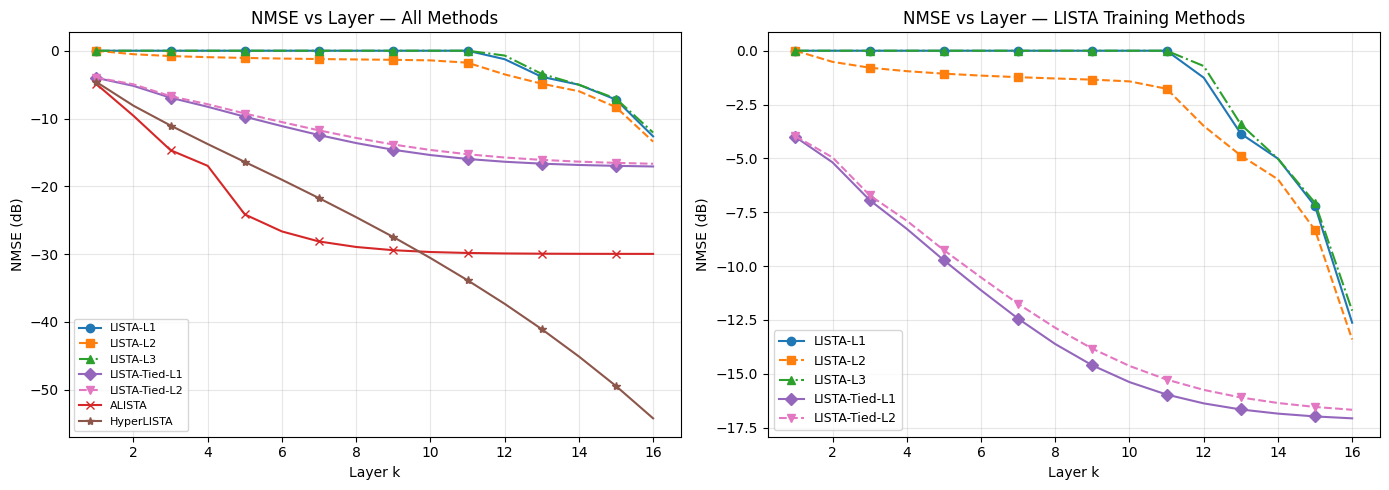

In [11]:
layers = list(range(1, K + 1))

colors = {
    'LISTA-L1':      '#1f77b4',
    'LISTA-L2':      '#ff7f0e',
    'LISTA-L3':      '#2ca02c',
    'LISTA-Tied-L1': '#9467bd',
    'LISTA-Tied-L2': '#e377c2',
    'ALISTA':        '#d62728',
    'HyperLISTA':    '#8c564b',
}
styles = {
    'LISTA-L1': '-',    'LISTA-L2': '--',  'LISTA-L3': '-.',
    'LISTA-Tied-L1': '-', 'LISTA-Tied-L2': '--',
    'ALISTA': '-',  'HyperLISTA': '-',
}
markers = {
    'LISTA-L1': 'o',    'LISTA-L2': 's',   'LISTA-L3': '^',
    'LISTA-Tied-L1': 'D', 'LISTA-Tied-L2': 'v',
    'ALISTA': 'x',  'HyperLISTA': '*',
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: all methods ---
ax = axes[0]
for name, res in RESULTS.items():
    ax.plot(layers, res['curve'], color=colors[name], linestyle=styles[name],
            marker=markers[name], markevery=2, label=name)
ax.set_xlabel('Layer k')
ax.set_ylabel('NMSE (dB)')
ax.set_title('NMSE vs Layer — All Methods')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# --- Right: LISTA variants only (zoom) ---
ax2 = axes[1]
lista_methods = ['LISTA-L1', 'LISTA-L2', 'LISTA-L3', 'LISTA-Tied-L1', 'LISTA-Tied-L2']
for name in lista_methods:
    if name in RESULTS:
        ax2.plot(layers, RESULTS[name]['curve'], color=colors[name],
                 linestyle=styles[name], marker=markers[name], markevery=2, label=name)
ax2.set_xlabel('Layer k')
ax2.set_ylabel('NMSE (dB)')
ax2.set_title('NMSE vs Layer — LISTA Training Methods')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
os.makedirs('../results/sparse', exist_ok=True)
plt.savefig('../results/sparse/training_methods_nmse_vs_layer.pdf', bbox_inches='tight')
plt.show()

### 10b. Summary Table

In [12]:
print(f'{'Method':<18} {'NMSE (dB)':>12} {'# Params':>12} {'Training':>16}')
print('-' * 62)
for name, res in RESULTS.items():
    t_str = f"{res['train_sec']/60:.1f} min" if res['train_sec'] is not None else 'checkpoint'
    print(f"{name:<18} {res['nmse_db']:>11.1f}  {res['n_params']:>11,}  {t_str:>15}")

Method                NMSE (dB)     # Params         Training
--------------------------------------------------------------
LISTA-L1                 -12.6    6,000,016          1.0 min
LISTA-L2                 -13.4    6,000,016          1.2 min
LISTA-L3                 -12.1    6,000,016          3.8 min
LISTA-Tied-L1            -17.1      375,001          0.8 min
LISTA-Tied-L2            -16.7      375,001          1.0 min
ALISTA                   -30.0           32       checkpoint
HyperLISTA               -54.1            3       checkpoint


### 10c. Parameters vs Final NMSE

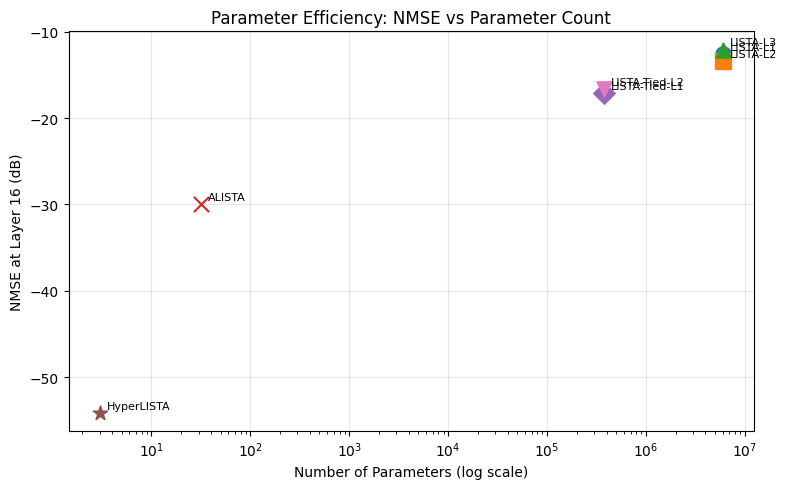


Key takeaway: more domain structure (tied → analytic W → adaptive) yields
better NMSE with exponentially fewer parameters.


In [13]:
fig, ax = plt.subplots(figsize=(8, 5))

for name, res in RESULTS.items():
    ax.scatter(res['n_params'], res['nmse_db'],
               color=colors[name], marker=markers[name], s=120, zorder=3)
    ax.annotate(name, (res['n_params'], res['nmse_db']),
                textcoords='offset points', xytext=(5, 3), fontsize=8)

ax.set_xscale('log')
ax.set_xlabel('Number of Parameters (log scale)')
ax.set_ylabel('NMSE at Layer 16 (dB)')
ax.set_title('Parameter Efficiency: NMSE vs Parameter Count')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../results/sparse/training_methods_params_vs_nmse.pdf', bbox_inches='tight')
plt.show()

print('\nKey takeaway: more domain structure (tied → analytic W → adaptive) yields')
print('better NMSE with exponentially fewer parameters.')